- Catrgorical>Nominal data: the catogories dont have any order or relation with each other

    + EX: State, Gender, etc (value of each is equal)

* Categorical>Ordinal data: catogries have a relation/ order between each other

    * EX: app reviews: Excelent>Good>bad

* let input columns(x) & output column(y)

    * if x contains a col which is **Ordinal categorical data** then use *Ordinal Encoder* on x col

    * if y is categorical(classification: yes,no) use **Label encoder** on y col

**Encoding = converting a catogory to a number**

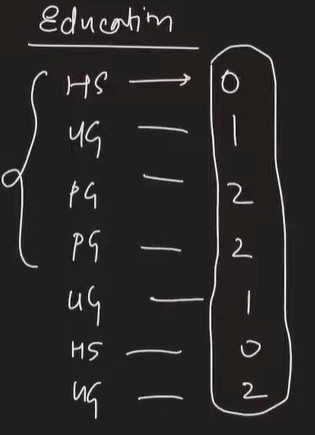

# Code

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('customer.csv')

In [6]:
df.sample(5)

,age,gender,review,education,purchased
17,22,Female,Poor,UG,Yes
24,16,Female,Average,PG,Yes
32,92,Male,Average,UG,Yes
40,39,Male,Good,School,No
30,73,Male,Average,UG,No


gender - required *one hot encoder* as its in x and its categorical>nominal data

review, education - requires *ordinal encoding* as its categorical>ordinal data

purchased - requires *Label encoder* as its in y and its categorical>ordinal data

In [9]:
df = df.iloc[:,2:]

In [11]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop(columns=['purchased']),
                                                df['purchased'],
                                                test_size=0.2,
                                                random_state=0)

In [33]:
X_train.head()

,review,education
33,Good,PG
35,Poor,School
26,Poor,PG
34,Average,School
18,Good,School


# Main

In [34]:
from sklearn.preprocessing import OrdinalEncoder

In [35]:
oe = OrdinalEncoder(categories=[['Poor','Average', 'Good'],['School','UG','PG']])

Here, *poor - 0, avg - 1, good - 2*. Left to right values assigned

In [36]:
oe.fit(X_train)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Poor', 'Average', ...], ['School', 'UG', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [37]:
X_train = oe.transform(X_train)
X_test = oe.transform(X_test)

Fit only X_train but transform both X_train and X_test

In [41]:
X_train

array([[2., 2.],
       [0., 0.],
       [0., 2.],
       [1., 0.],
       [2., 0.],
       [0., 0.],
       [0., 2.],
       [0., 2.],
       [2., 1.],
       [1., 1.],
       [0., 1.],
       [1., 1.],
       [1., 1.],
       [0., 1.],
       [2., 2.],
       [1., 0.],
       [0., 2.],
       [1., 1.],
       [1., 0.],
       [2., 0.],
       [1., 0.],
       [0., 1.],
       [2., 0.],
       [2., 1.],
       [0., 1.],
       [0., 0.],
       [1., 2.],
       [1., 2.],
       [2., 0.],
       [2., 0.],
       [2., 1.],
       [1., 2.],
       [0., 2.],
       [2., 1.],
       [0., 2.],
       [0., 2.],
       [2., 2.],
       [1., 0.],
       [2., 2.],
       [1., 1.]])

In [44]:
from sklearn.preprocessing import LabelEncoder

In [48]:
le = LabelEncoder()

In [49]:
 le.fit(Y_train)

LabelEncoder()

In [50]:
Y_train = le.transform(Y_train)
Y_test = le.transform(Y_test)

In [51]:
Y_train

array([1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [53]:
le.classes_ # this way u chan see which is 0,1, here NO=0, Yes=1

array(['No', 'Yes'], dtype=object)